# **Librerias**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


# **Lectura de los datos y Unión de DataFrames**

Primero de todo, leemos los .csv para poder trabajar con ellos en dataframes.

In [2]:
df_stores = pd.read_csv("../data/raw/stores.csv")
df_holidays = pd.read_csv("../data/raw/holidays_events.csv")
df_oil = pd.read_csv("../data/raw/oil.csv")
df_transactions = pd.read_csv("../data/raw/transactions.csv")
df_train= pd.read_csv("../data/raw/train.csv")

A continuación, leemos uno a uno, con el fin de poder saber qué tipo de datos vamos a analizar y saber qué campo que relacionar entre ellas para juntar todos los .csv en un único dataframe.

In [3]:
print("-----------------")
print("Stores")
df_stores.info()
df_stores.head()

-----------------
Stores
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [4]:
print("-----------------")
print("Holidays")
df_holidays.info()
df_holidays.head()

-----------------
Holidays
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         350 non-null    object
 1   type         350 non-null    object
 2   locale       350 non-null    object
 3   locale_name  350 non-null    object
 4   description  350 non-null    object
 5   transferred  350 non-null    bool  
dtypes: bool(1), object(5)
memory usage: 14.1+ KB


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [5]:
print("-----------------")
print("Oil")
df_oil.info()
df_oil.head()

-----------------
Oil
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [6]:
print("-----------------")
print("Transactions")
df_transactions.info()
df_transactions.head()

-----------------
Transactions
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          83488 non-null  object
 1   store_nbr     83488 non-null  int64 
 2   transactions  83488 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.9+ MB


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [7]:
print("-----------------")
print("Train Dataset")
df_train.info()
df_train.head()


-----------------
Train Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


Procedemos con la unión de los .csv en dataframes con la función .merge, donde le pasamos como parámetro el campo a unir y el tipo de join, en nuestro caso hemos optado por el left, ya que queremos mostrar del primer dataframe (izquierda).

In [8]:
df_final = pd.merge(df_train, df_stores, on='store_nbr', how='left')

df_final = pd.merge(df_final, df_transactions, on=['date', 'store_nbr'], how='left')

df_final = pd.merge(df_final, df_oil, on='date', how='left')

df_final = pd.merge(df_final, df_holidays, on='date', how='left')



Hemos detectado que el campo 'date', no es reconocido como fecha, por lo que como primera transfromación de los datos es cambiar el campo 'date' como fecha. Además, hemos creado nuevas columnas utilizando el campo 'date' como referencia (año, mes, día de la semana y si es finde semana o no), ya que el tráfico de clientes de una tienda podría cambiar en función del día de la semana.

In [9]:
df_final['date'] = pd.to_datetime(df_final['date'])
df_final =df_final.sort_values('date').reset_index(drop=True)

df_final['year'] = df_final['date'].dt.year
df_final['month'] = df_final['date'].dt.month
df_final['day_of_week'] = df_final['date'].dt.dayofweek

En cuanto a la partición entre el df_train y el df_test, al tener datos en una serie temporal, la división de estos se lleva a cabo a través de la fecha. En donde los datos inferiores al 2017 se asignan al df_train y aquellos superiores o igual a la fecha de corte se asignan al df_test para comprobar la capacidad predictiva del modelo.

In [10]:
fecha_corte = '2017-01-01'
# idx = int(0.8 * df_final.shape[0])
# df_train = df_final.iloc[:idx, :]
# df_test = df_final.iloc[idx:, :]

df_train = df_final[df_final['date']< fecha_corte]
df_test = df_final[df_final['date'] >= fecha_corte]

df_train.to_csv("../data/raw/df_train.csv",index=False)
df_test.to_csv("../data/raw/df_test.csv",index=False)

In [11]:
#Comprobación de que la partición haya salido con éxtio
df_train['date'].min(), df_train['date'].max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2016-12-31 00:00:00'))

In [12]:
#Comprobación de que la partición haya salido con éxtio
df_test['date'].min(), df_test['date'].max()

(Timestamp('2017-01-01 00:00:00'), Timestamp('2017-08-15 00:00:00'))

Comprobar que el peso de cada partición sea óptimo, es decir, el porcentaje de partición de los datos de la serie temporal.

In [13]:
print(f"% Train: {df_train.shape[0]/df_final.shape[0]} , % Test: {df_test.shape[0]/df_final.shape[0]}")

% Train: 0.8652275379229871 , % Test: 0.13477246207701282


# **Exploración de los datos**

Una vez obtenido el df_final, con todas las columnas en un único dataframe, vamos a observar los datos detalladamente.

In [14]:
df_train

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,transactions,dcoilwtico,type_y,locale,locale_name,description,transferred,year,month,day_of_week
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False,2013,1,1
1,1194,2013-01-01,42,CELEBRATION,0.000,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False,2013,1,1
2,1193,2013-01-01,42,BREAD/BAKERY,0.000,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False,2013,1,1
3,1192,2013-01-01,42,BOOKS,0.000,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False,2013,1,1
4,1191,2013-01-01,42,BEVERAGES,0.000,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False,2013,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2642701,2595184,2016-12-31,25,SCHOOL AND OFFICE SUPPLIES,0.000,0,Salinas,Santa Elena,D,1,3401.0,NaN,Additional,National,Ecuador,Primer dia del ano-1,False,2016,12,5
2642702,2595185,2016-12-31,25,SEAFOOD,29.634,1,Salinas,Santa Elena,D,1,3401.0,NaN,Additional,National,Ecuador,Primer dia del ano-1,False,2016,12,5
2642703,2595186,2016-12-31,26,AUTOMOTIVE,13.000,0,Guayaquil,Guayas,D,10,1478.0,NaN,Additional,National,Ecuador,Primer dia del ano-1,False,2016,12,5
2642704,2595187,2016-12-31,26,BABY CARE,0.000,0,Guayaquil,Guayas,D,10,1478.0,NaN,Additional,National,Ecuador,Primer dia del ano-1,False,2016,12,5


En primer lugar, detectamos que hay nombres que cuestan entenderlos, por lo que vamos a cambiar el nombre de estas y asi facilitar a la hora de analizarlos. Tanto en el df_train como el df_test.

In [15]:
df_train.rename(columns={'type_x': 'type_store', 'type_y': 'type_holiday', 'dcoilwtico': 'oil_price'}, inplace=True)
df_test.rename(columns={'type_x': 'type_store', 'type_y': 'type_holiday', 'dcoilwtico': 'oil_price'}, inplace=True)

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_22444\2818501641.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.rename(columns={'type_x': 'type_store', 'type_y': 'type_holiday', 'dcoilwtico': 'oil_price'}, inplace=True)
C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_22444\2818501641.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test.rename(columns={'type_x': 'type_store', 'type_y': 'type_holiday', 'dcoilwtico': 'oil_price'}, inplace=True)


Ahora una vez, renombrado las columnas, vamos a comprobar que los tipos de las variables son correctos. En nuestro caso, hemos visto que hay variables que deberían tratarse como categóricas, en cambio en el dataframe inicial se detectan como numéricas.

In [16]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2642706 entries, 0 to 2642705
Data columns (total 20 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[ns]
 2   store_nbr     int64         
 3   family        object        
 4   sales         float64       
 5   onpromotion   int64         
 6   city          object        
 7   state         object        
 8   type_store    object        
 9   cluster       int64         
 10  transactions  float64       
 11  oil_price     float64       
 12  type_holiday  object        
 13  locale        object        
 14  locale_name   object        
 15  description   object        
 16  transferred   object        
 17  year          int32         
 18  month         int32         
 19  day_of_week   int32         
dtypes: datetime64[ns](1), float64(3), int32(3), int64(4), object(9)
memory usage: 393.2+ MB


In [17]:
df_train.shape

(2642706, 20)

Procedemos a dividir el dataframe en un lista con las columnas categóricas y numéricas, previas a su análisis individual

In [18]:
cat = df_train.select_dtypes(include=['object', 'bool']).columns.tolist()
num = df_train.select_dtypes(exclude=['object']).columns.tolist()

print(f"Variables categóricas {cat}")
print("--------------------------------")
print(f"Variables numéricas {num}")

Variables categóricas ['family', 'city', 'state', 'type_store', 'type_holiday', 'locale', 'locale_name', 'description', 'transferred']
--------------------------------
Variables numéricas ['id', 'date', 'store_nbr', 'sales', 'onpromotion', 'cluster', 'transactions', 'oil_price', 'year', 'month', 'day_of_week']


In [19]:
df_train[num].describe(percentiles= [.25 , .5, .75, .9, .95, .99]).T

,count,mean,min,25%,50%,75%,90%,95%,99%,max,std
id,2642706.0,1302440.228928,0.0,651766.25,1301750.5,1955298.75,2335666.5,2467801.75,2571727.95,2596373.0,750272.745809
date,2642706,2015-01-02 21:50:51.382332672,2013-01-01 00:00:00,2014-01-02 00:00:00,2015-01-03 00:00:00,2016-01-06 00:00:00,2016-08-06 00:00:00,2016-10-19 00:00:00,2016-12-17 00:00:00,2016-12-31 00:00:00,NaN
store_nbr,2642706.0,27.5,1.0,14.0,27.5,41.0,49.0,52.0,54.0,54.0,15.585787
sales,2642706.0,339.994847,0.0,0.0,9.0,185.0,822.0,1852.0,5263.0,124717.0,1061.583133
onpromotion,2642706.0,1.963957,0.0,0.0,0.0,0.0,2.0,8.0,49.0,741.0,11.038151
cluster,2642706.0,8.481481,1.0,4.0,8.5,13.0,15.0,15.0,17.0,17.0,4.649735
transactions,2398935.0,1704.314726,5.0,1049.0,1399.0,2103.0,3079.0,3724.0,4905.0,8359.0,972.020822
oil_price,1822986.0,70.838446,26.19,46.28,60.01,97.1,103.54,105.88,108.0,110.62,26.420837
year,2642706.0,2014.506406,2013.0,2014.0,2015.0,2016.0,2016.0,2016.0,2016.0,2016.0,1.120125
month,2642706.0,6.521241,1.0,4.0,7.0,9.0,11.0,12.0,12.0,12.0,3.430073


In [20]:
df_train[cat].describe(include='object').T

,count,unique,top,freq
family,2642706,33,AUTOMOTIVE,80082
city,2642706,22,Quito,880902
state,2642706,16,Pichincha,929841
type_store,2642706,5,D,880902
type_holiday,449064,6,Holiday,265518
locale,449064,3,National,240570
locale_name,449064,24,Ecuador,240570
description,449064,100,Carnaval,14256
transferred,449064,2,False,440154


In [21]:
df_train.isnull().sum()

id                    0
date                  0
store_nbr             0
family                0
sales                 0
onpromotion           0
city                  0
state                 0
type_store            0
cluster               0
transactions     243771
oil_price        819720
type_holiday    2193642
locale          2193642
locale_name     2193642
description     2193642
transferred     2193642
year                  0
month                 0
day_of_week           0
dtype: int64

In [22]:
nulos_por_variable = ((df_train.isnull().sum() / df_train.shape[0]) * 100).round(2)

print(nulos_por_variable)

id               0.00
date             0.00
store_nbr        0.00
family           0.00
sales            0.00
onpromotion      0.00
city             0.00
state            0.00
type_store       0.00
cluster          0.00
transactions     9.22
oil_price       31.02
type_holiday    83.01
locale          83.01
locale_name     83.01
description     83.01
transferred     83.01
year             0.00
month            0.00
day_of_week      0.00
dtype: float64


Al haber detectado algunas columnas, que se deberían tratar como categóricas, procedemos a hacer los cambios. La principal razón por la que se deben tratar como categórica y no como numérica es porque al ser variables de identificación queremos que se traten de manera equitativa.

In [23]:
df_train = df_train.astype({'transferred': 'bool'})
df_test = df_test.astype({'transferred': 'bool'})

**Correlaciones**

# **Análisis Univariable**

## **1. Columnas numéricas**

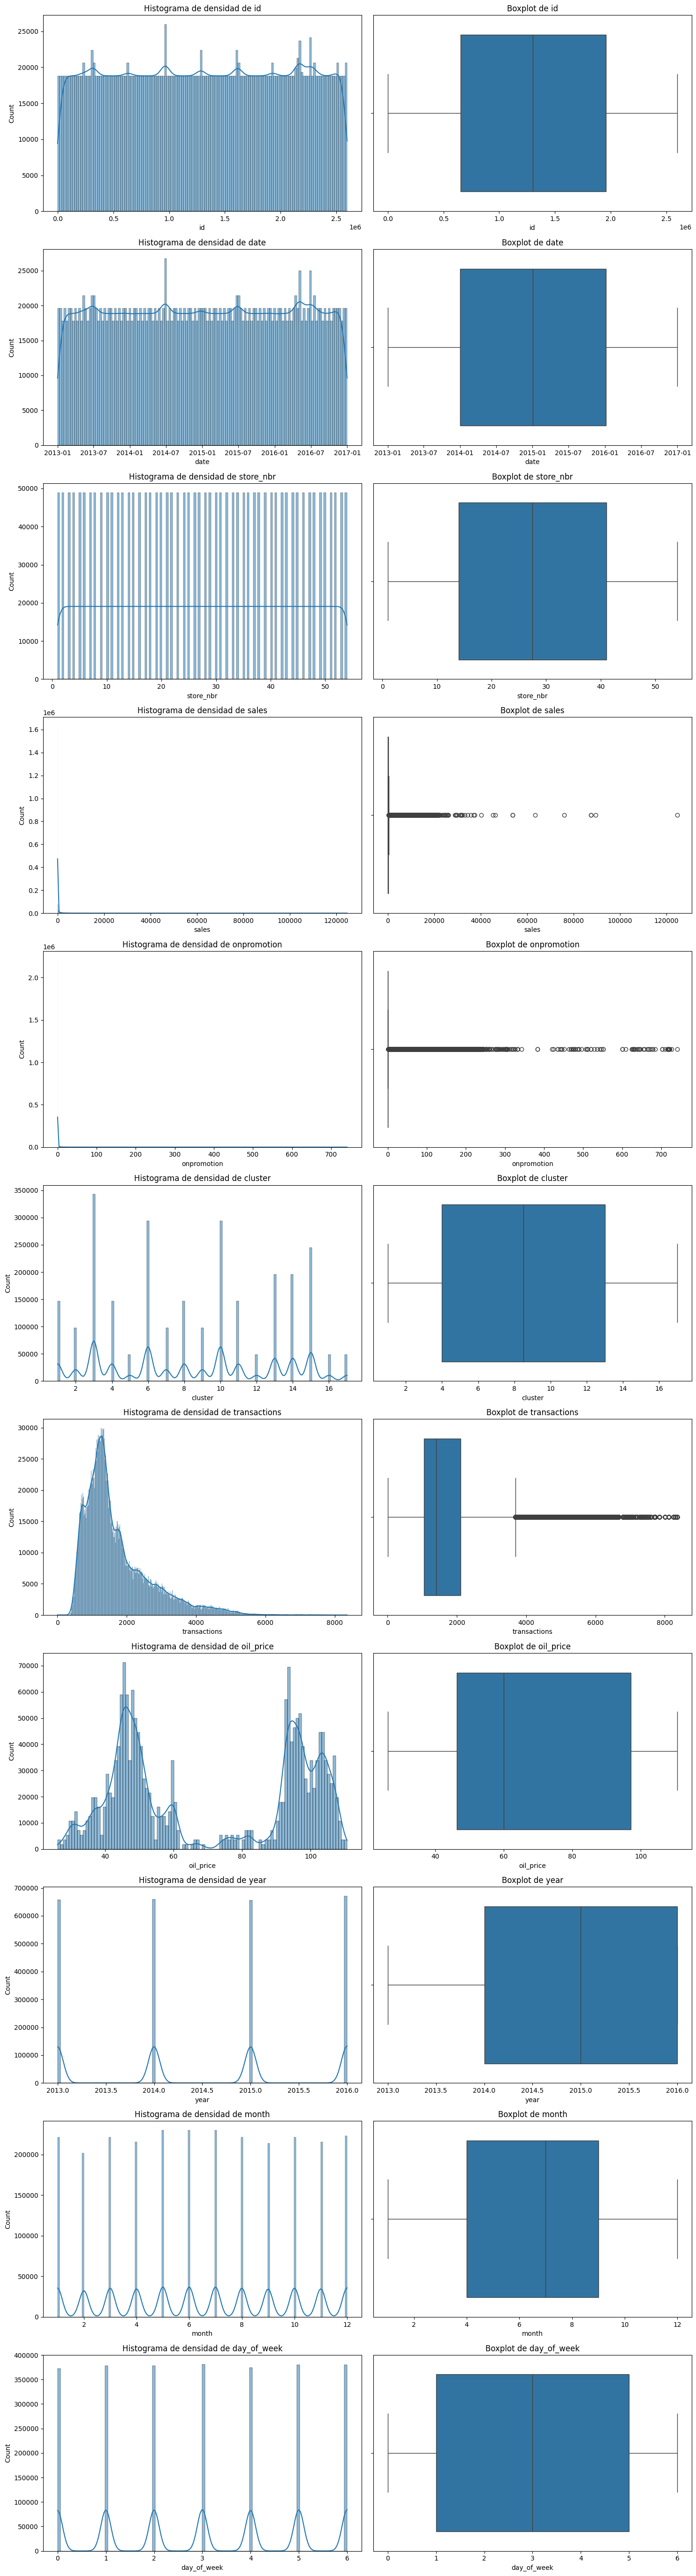

In [24]:
fig, axes = plt.subplots(nrows=len(num), ncols=2, figsize=(15, 5 * len(num)))

for i, column in enumerate(df_train[num]):
    # Histograma de densidad
    sns.histplot(df_train[column], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histograma de densidad de {column}')
    
    # Boxplot
    sns.boxplot(x=df_train[column], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot de {column}')

plt.tight_layout()
plt.show()

## **2. Columnas Categóricas**

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

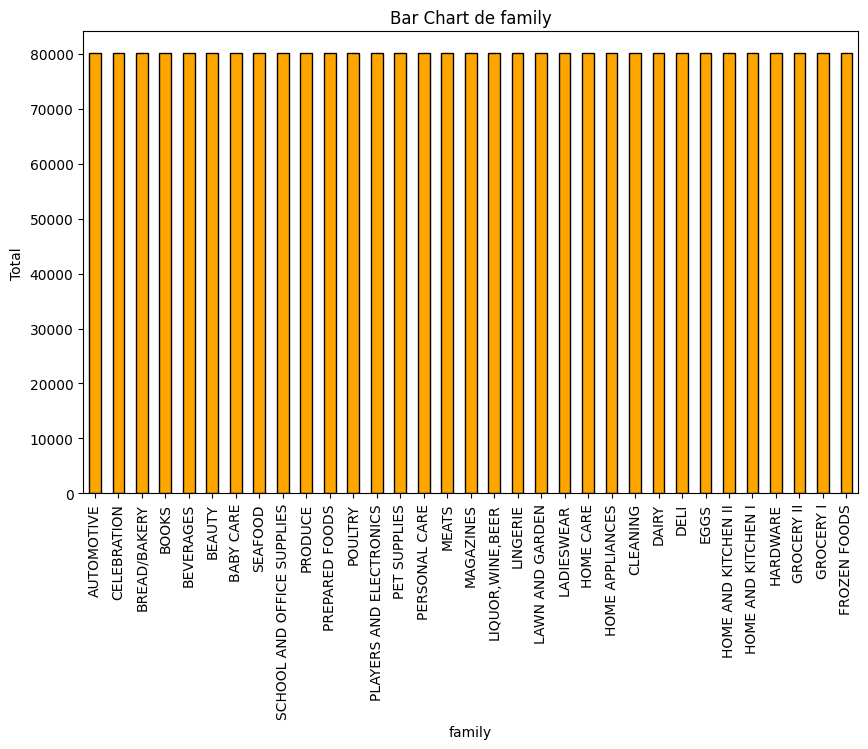

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

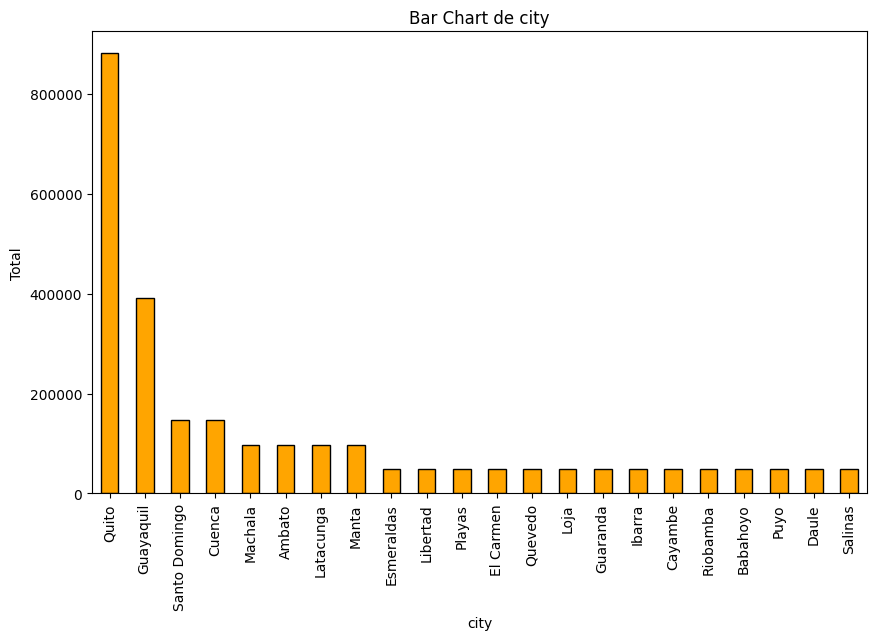

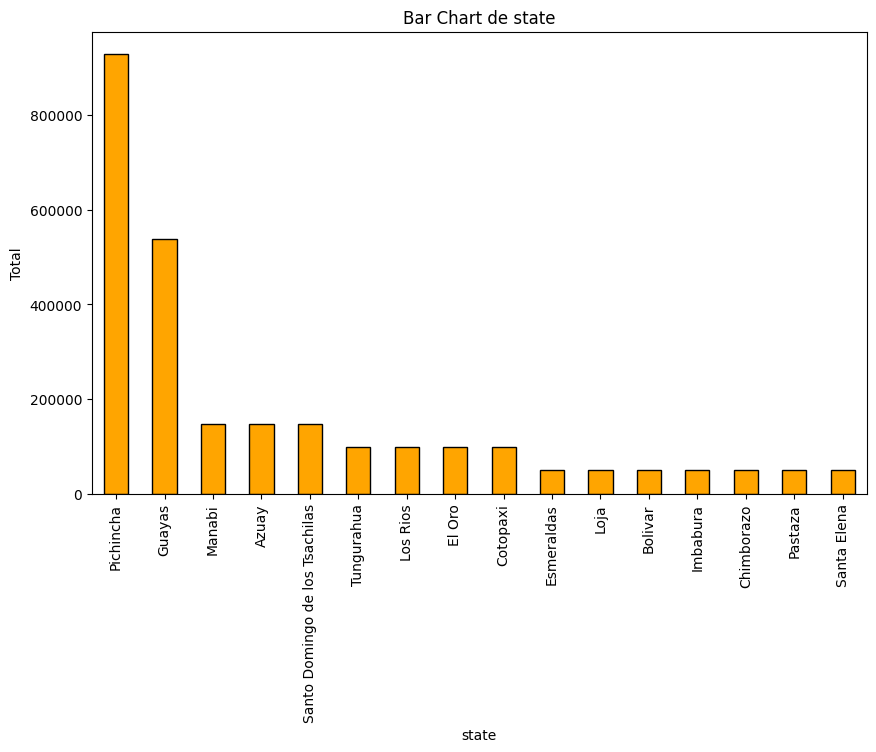

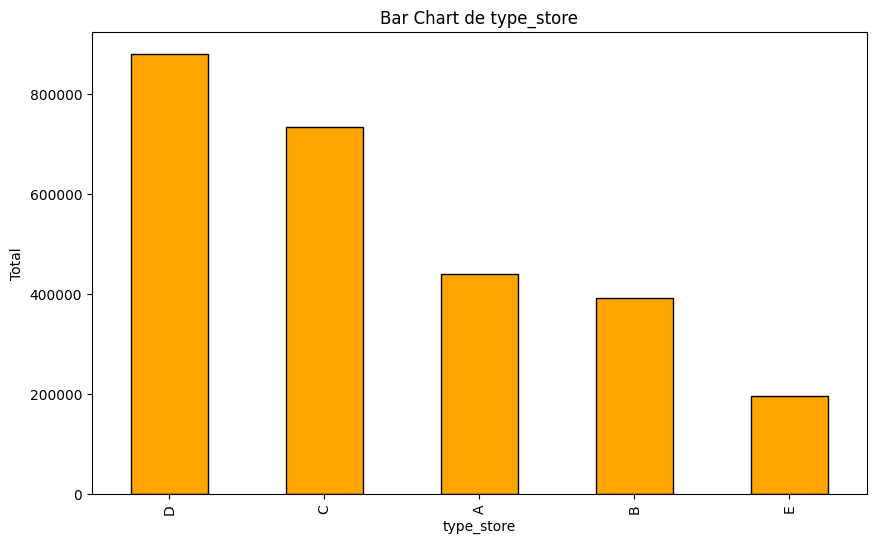

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

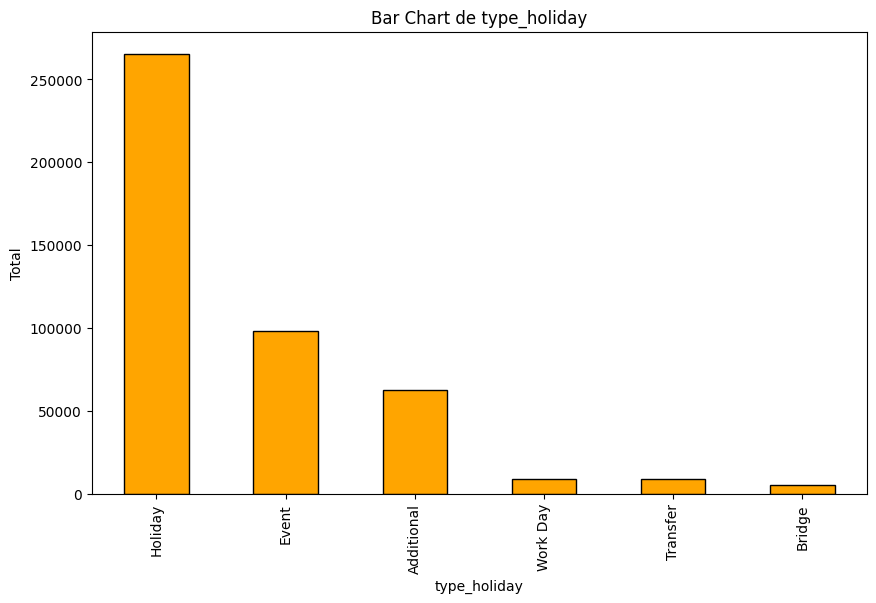

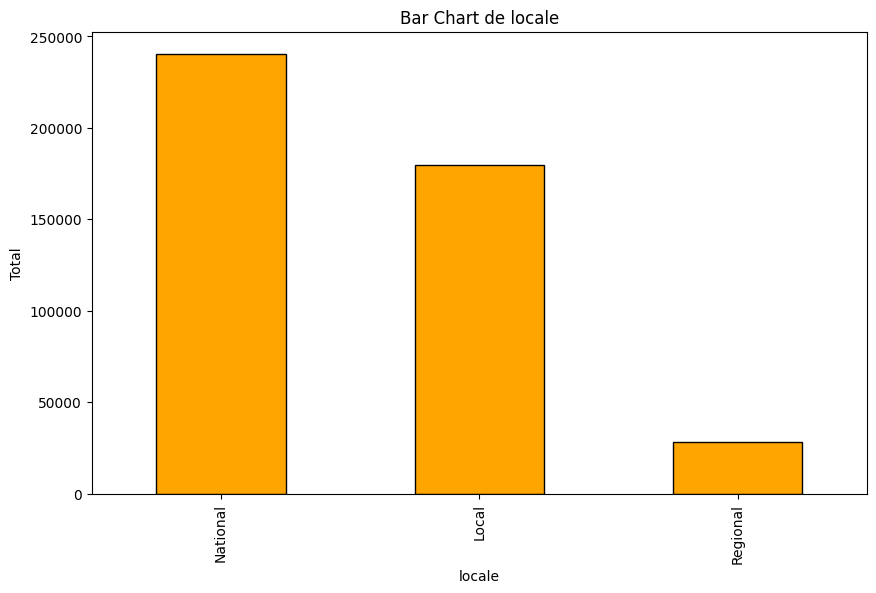

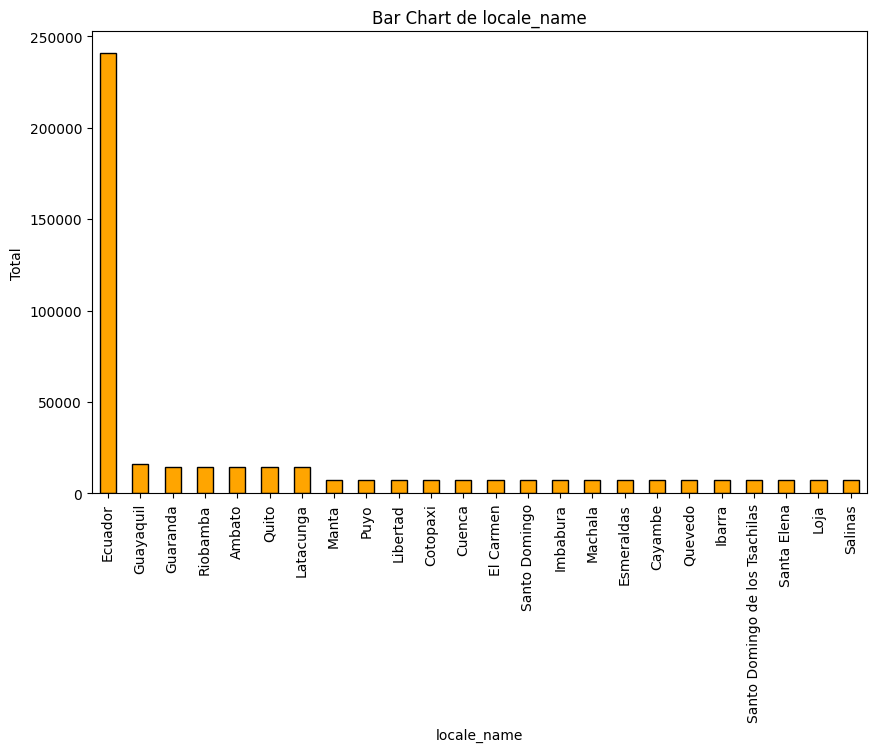

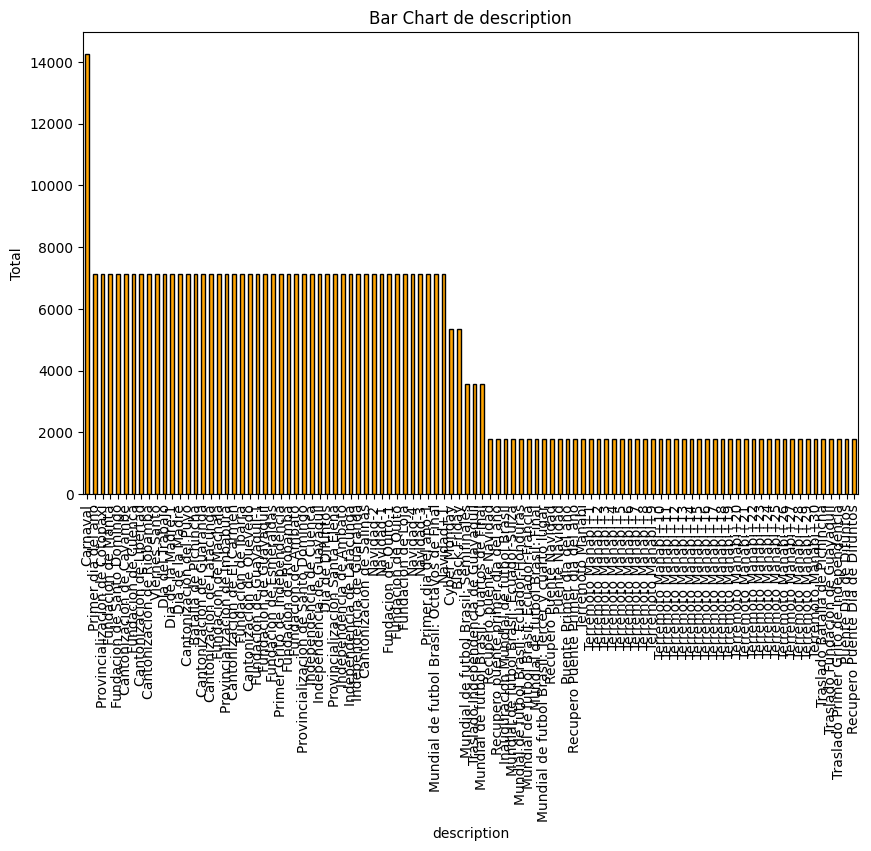

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [24]:
# Pintar la frecuencia por variable en gráfico de barras todas las columnas categóricas.
for column in df_train.columns:
    plt.figure(figsize=(10, 6))

    if isinstance(df_train[column].dtype, pd.CategoricalDtype) or df_train[column].dtype == 'object':
        df_train[column].value_counts().plot(kind='bar', color='orange', edgecolor='black')
        plt.title(f'Bar Chart de {column}')
        plt.xlabel(column)
        plt.ylabel('Total')
    
    plt.show()

## **Análisis Bivariable**

Nuestra variable objetiva son las ventas ('sales'), por lo que vamos a realizar un Análisis Bivariable sobre cada una de las variables.

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_22444\2905583641.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


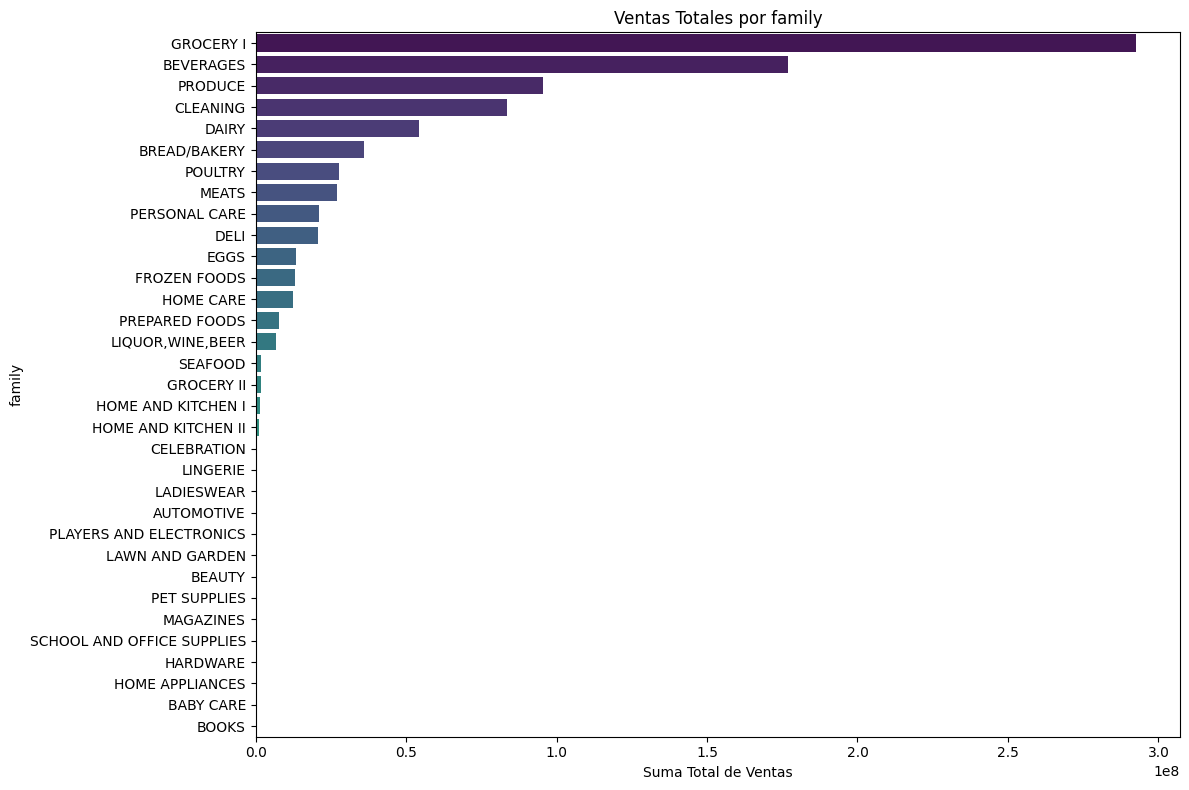

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_22444\2905583641.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


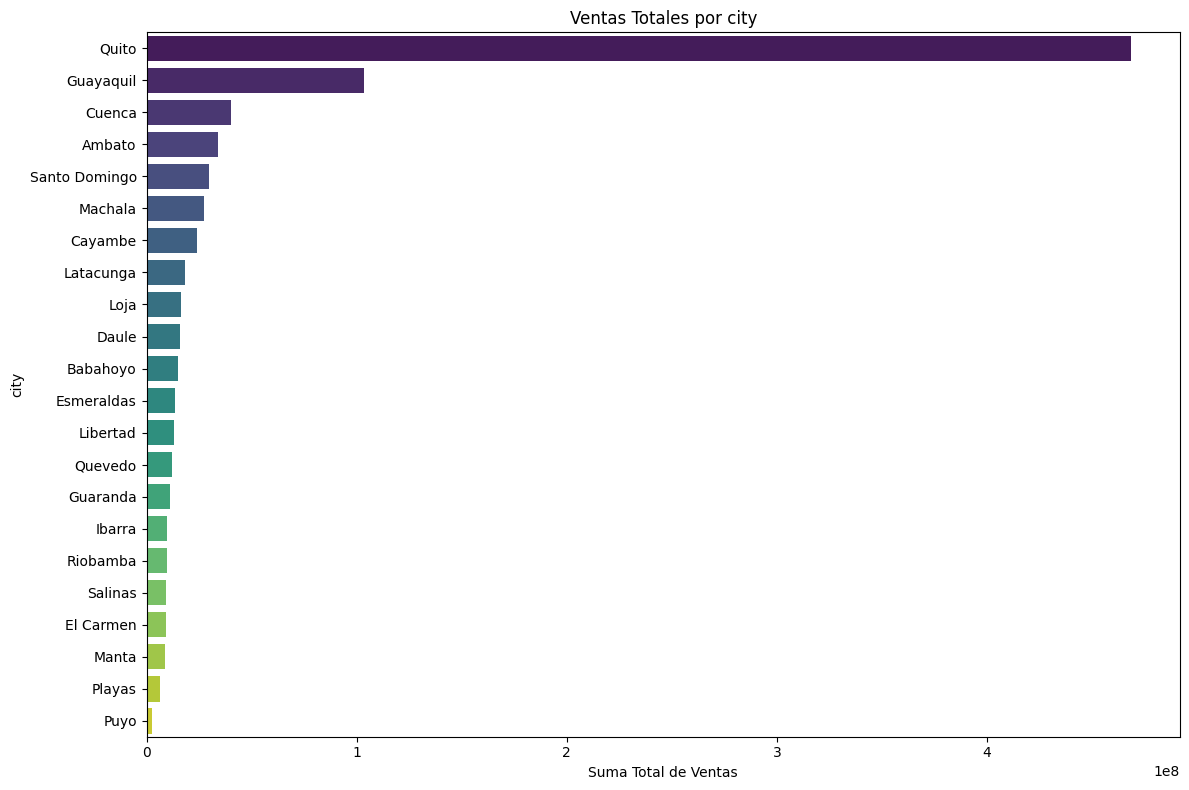

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_22444\2905583641.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


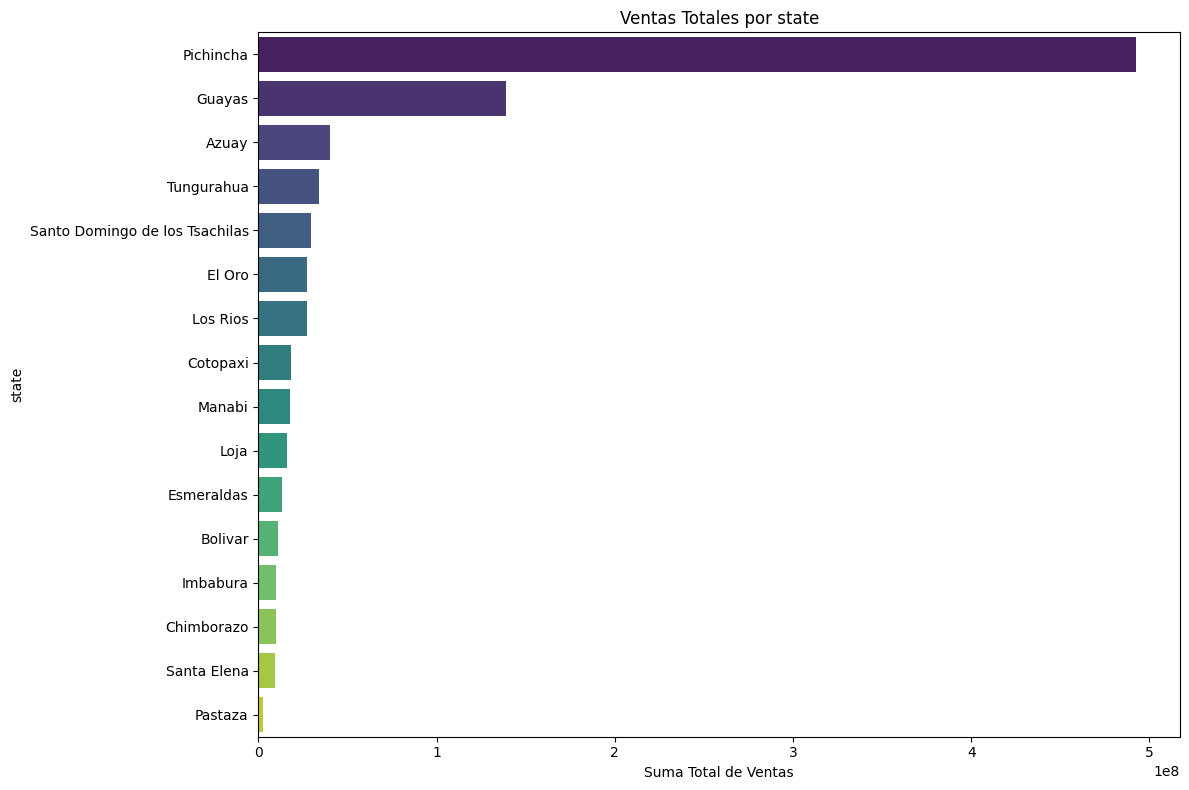

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_22444\2905583641.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


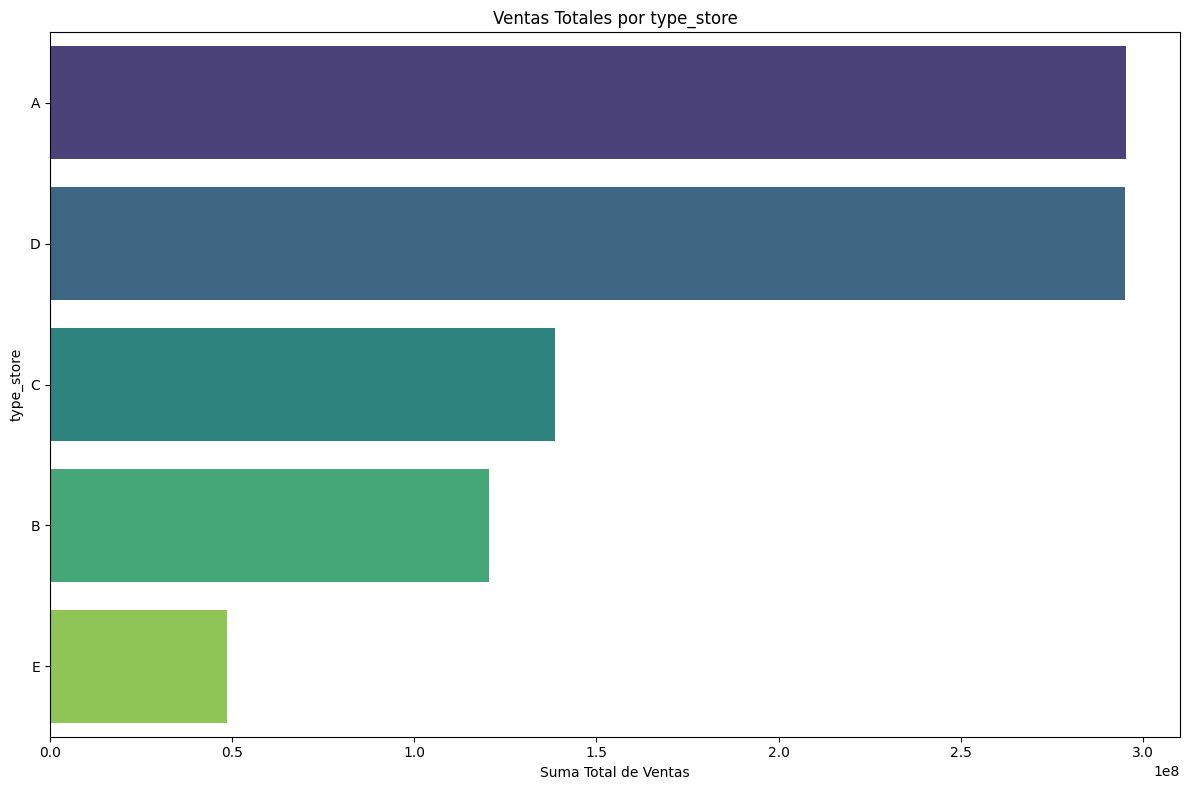

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_22444\2905583641.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


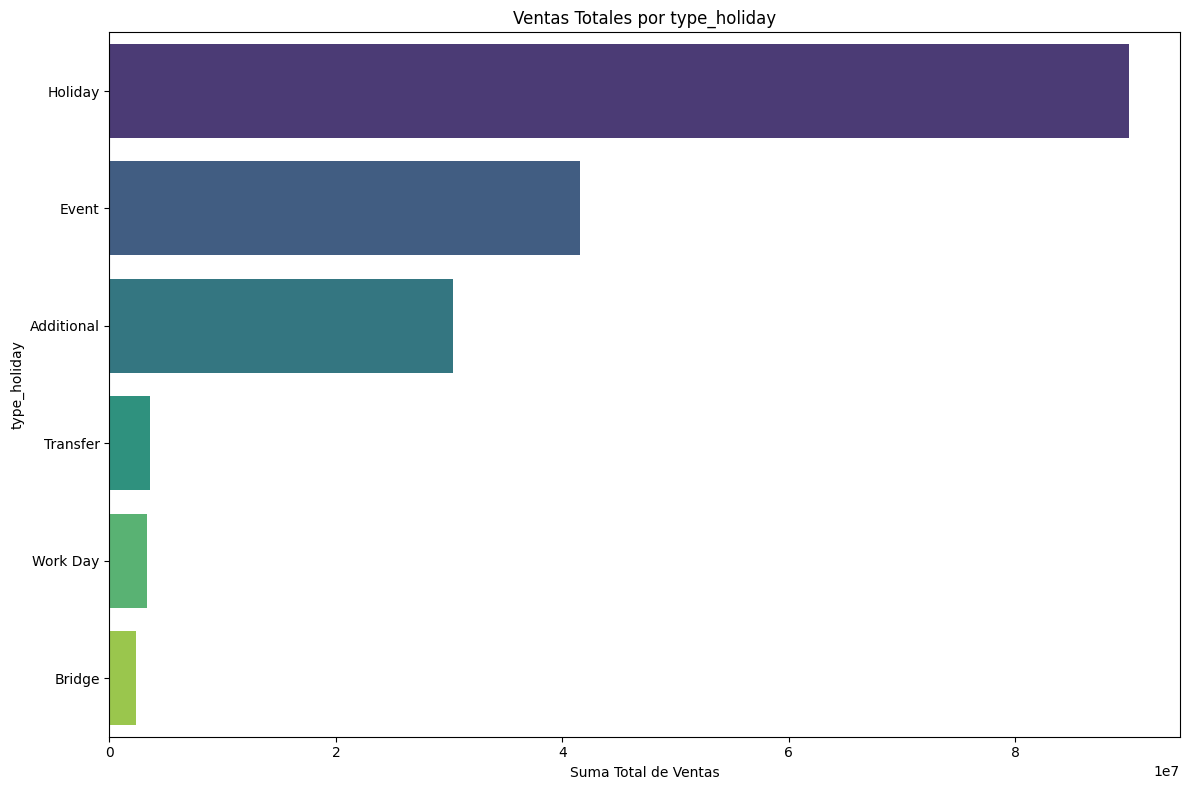

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_22444\2905583641.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


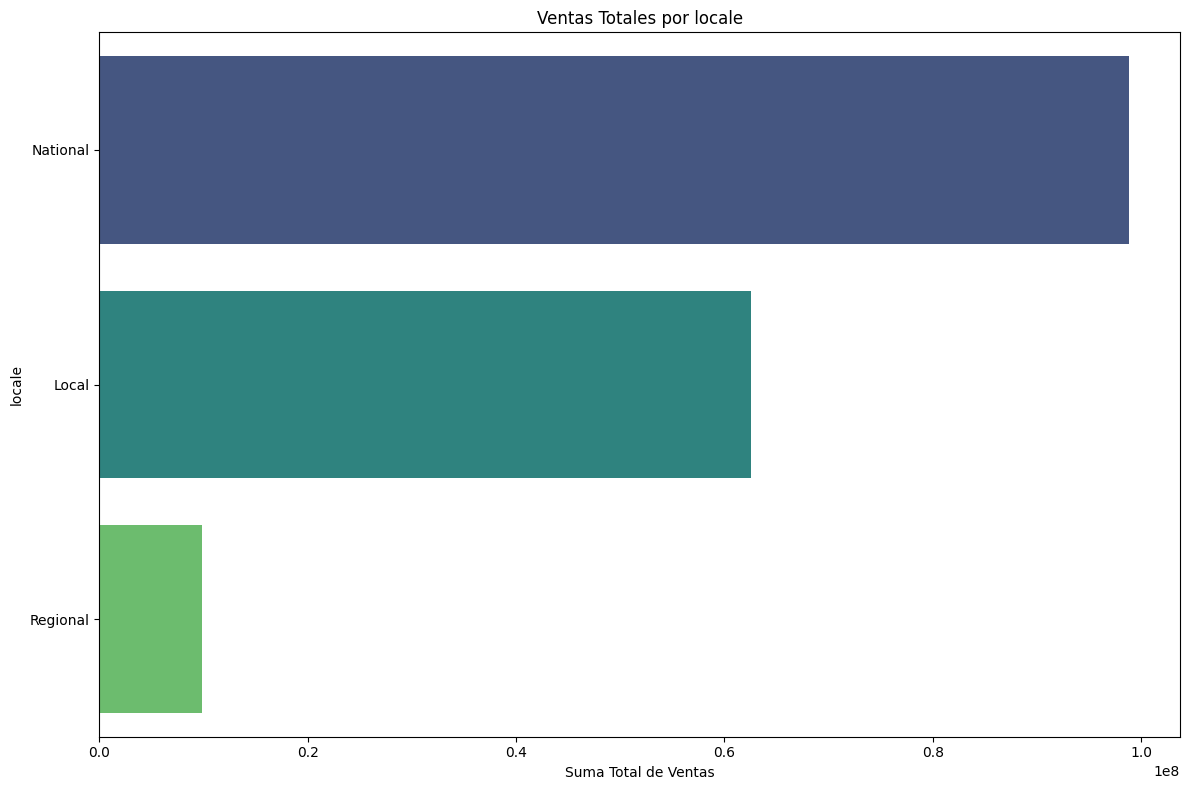

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_22444\2905583641.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


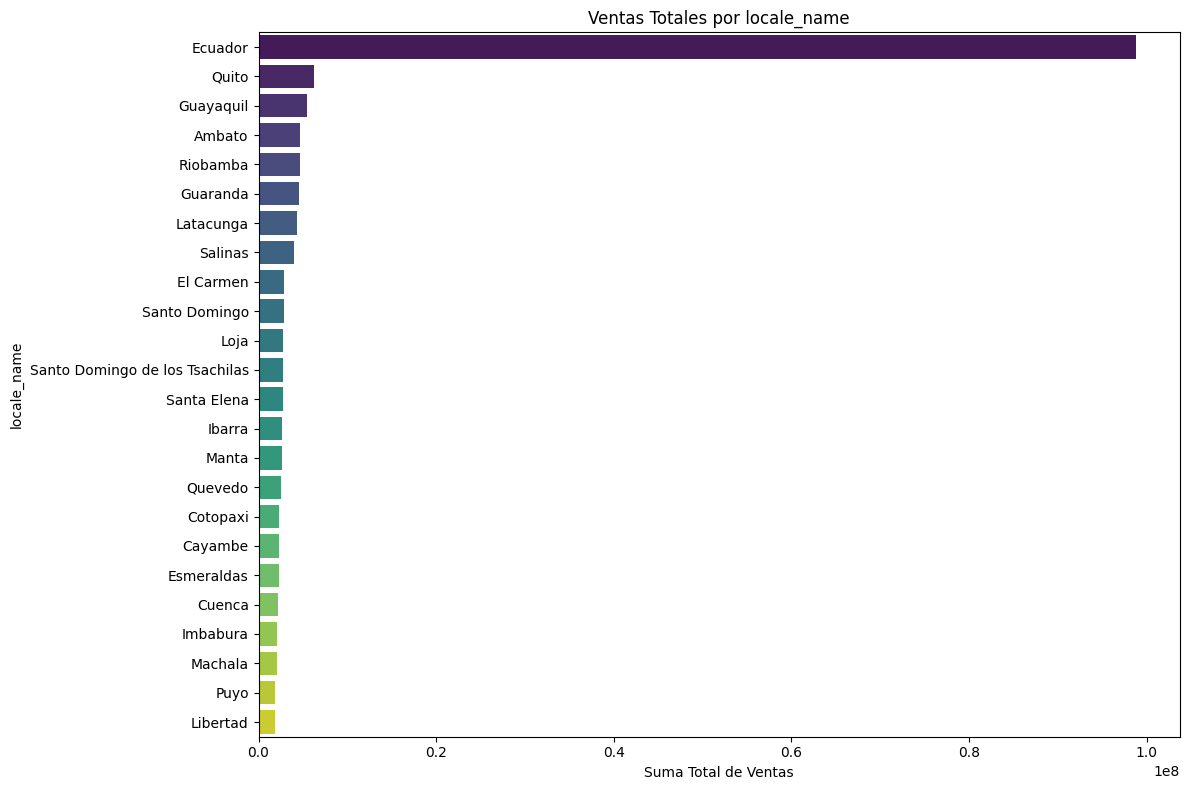

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_22444\2905583641.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


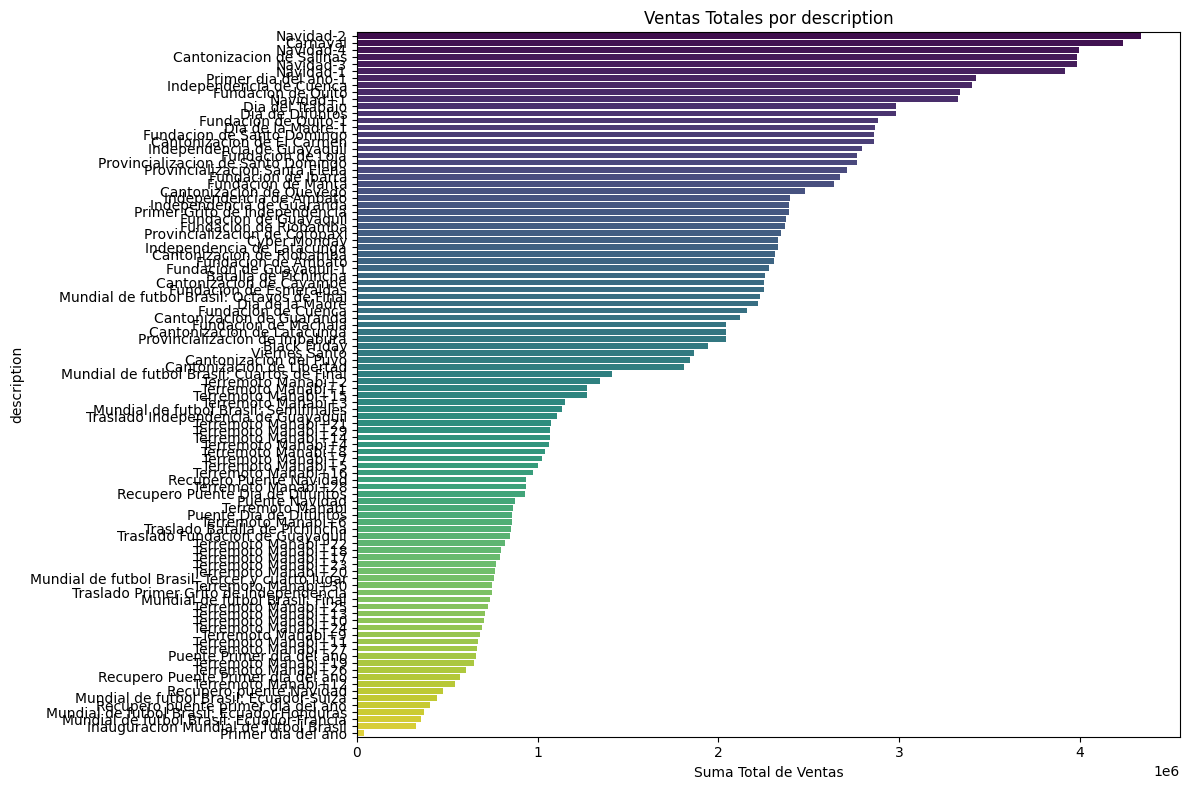

In [32]:
# Iteramos por todas las columnas del dataframe
for column in df_train.columns:
    
    # Comprobamos si la columna es categórica o tipo objeto
    if isinstance(df_train[column].dtype, pd.CategoricalDtype) or df_train[column].dtype == 'object':
        
        plt.figure(figsize=(12, 8))
        
        # 1. Agrupamos y sumamos ventas (esto hace que el gráfico cargue rápido)
        df_grouped = df_train.groupby(column)['sales'].sum().sort_values(ascending=False).reset_index()
        
        # 2. Dibujamos el gráfico de barras
        # Usamos la columna actual en el eje Y y las ventas en el eje X
        sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')
        
        # 3. Títulos y etiquetas
        plt.title(f'Ventas Totales por {column}')
        plt.xlabel('Suma Total de Ventas')
        plt.ylabel(column)
        
        plt.tight_layout()
        plt.show()

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_22444\43422427.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


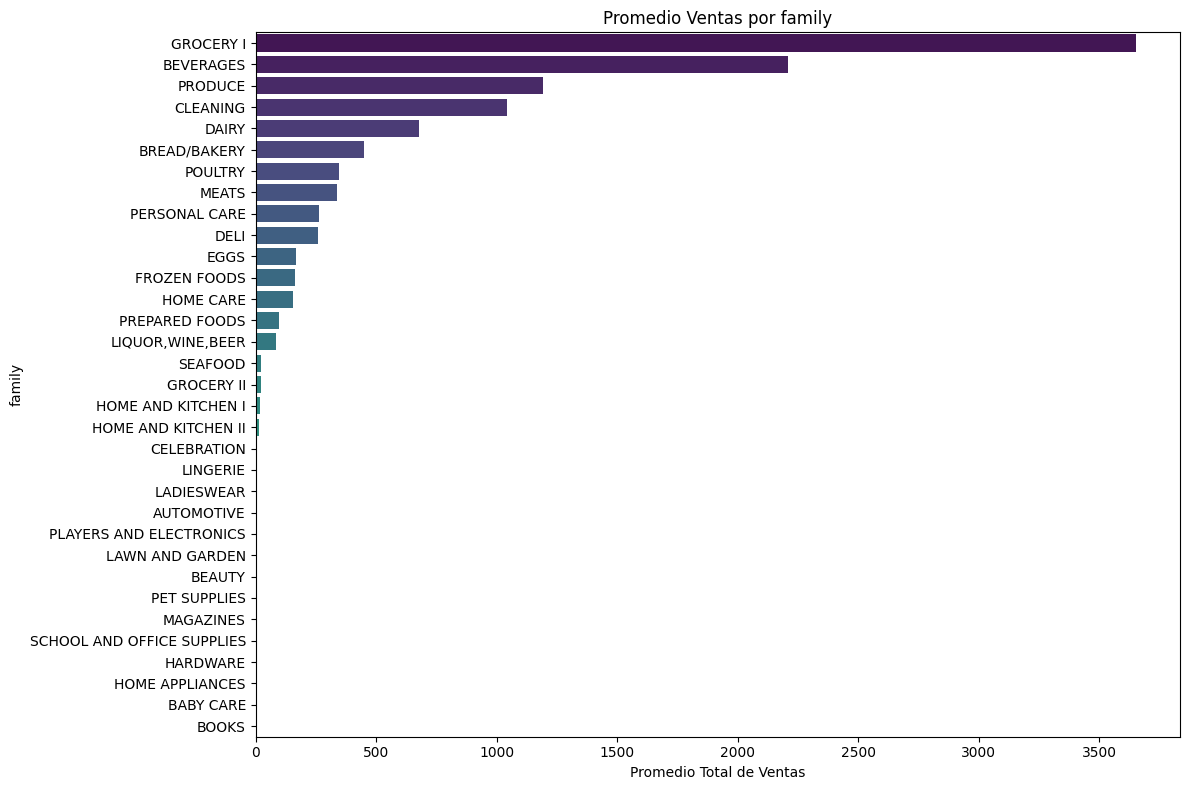

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_22444\43422427.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


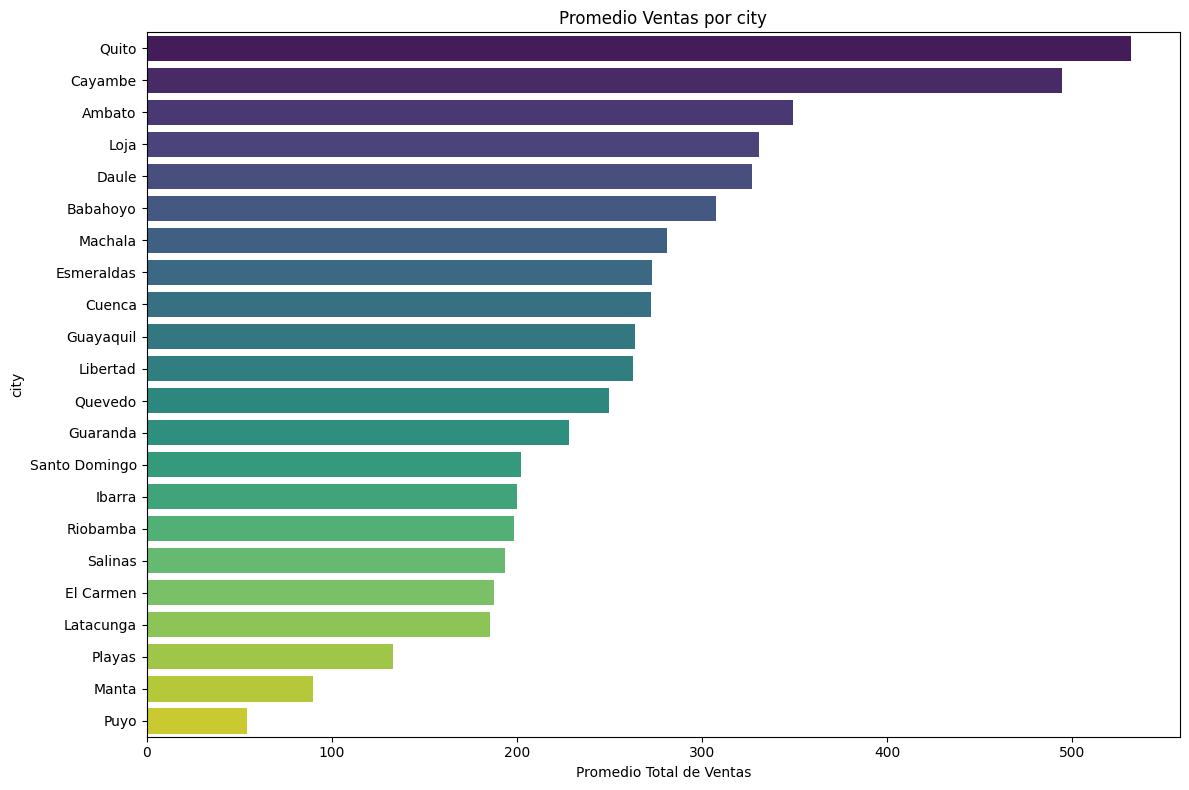

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_22444\43422427.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


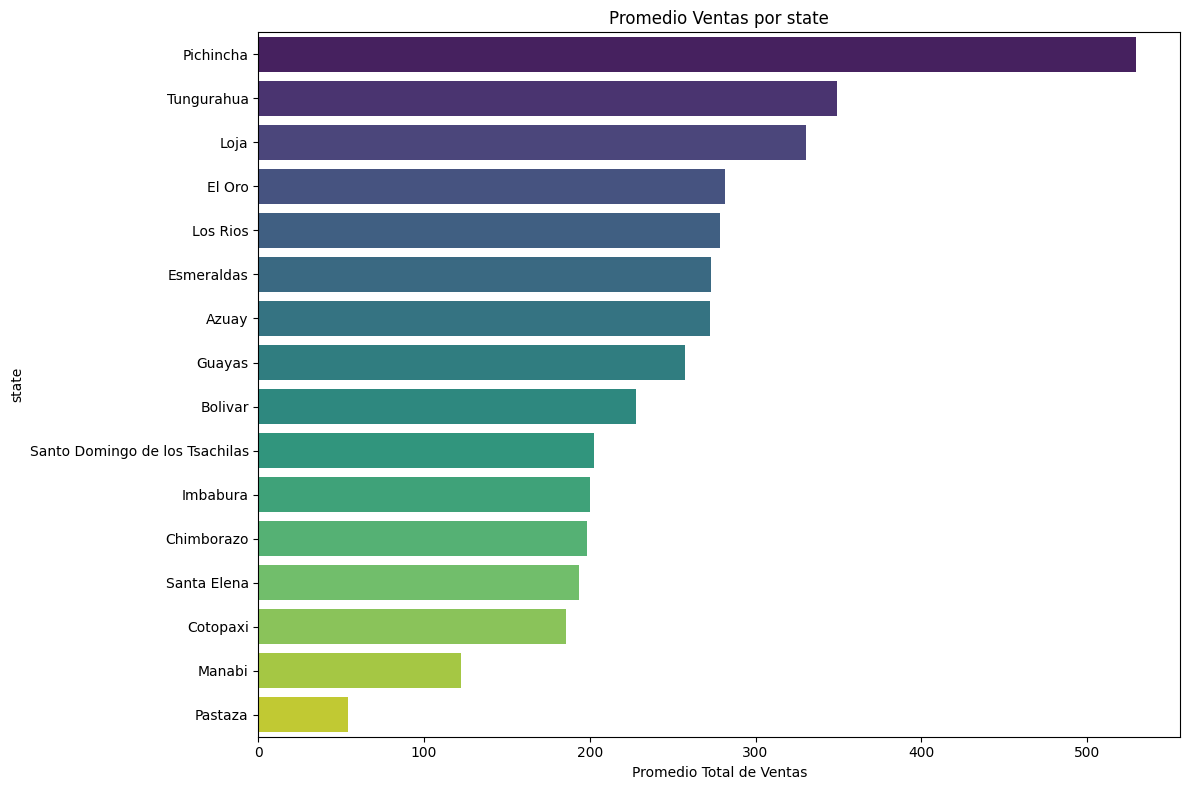

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_22444\43422427.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


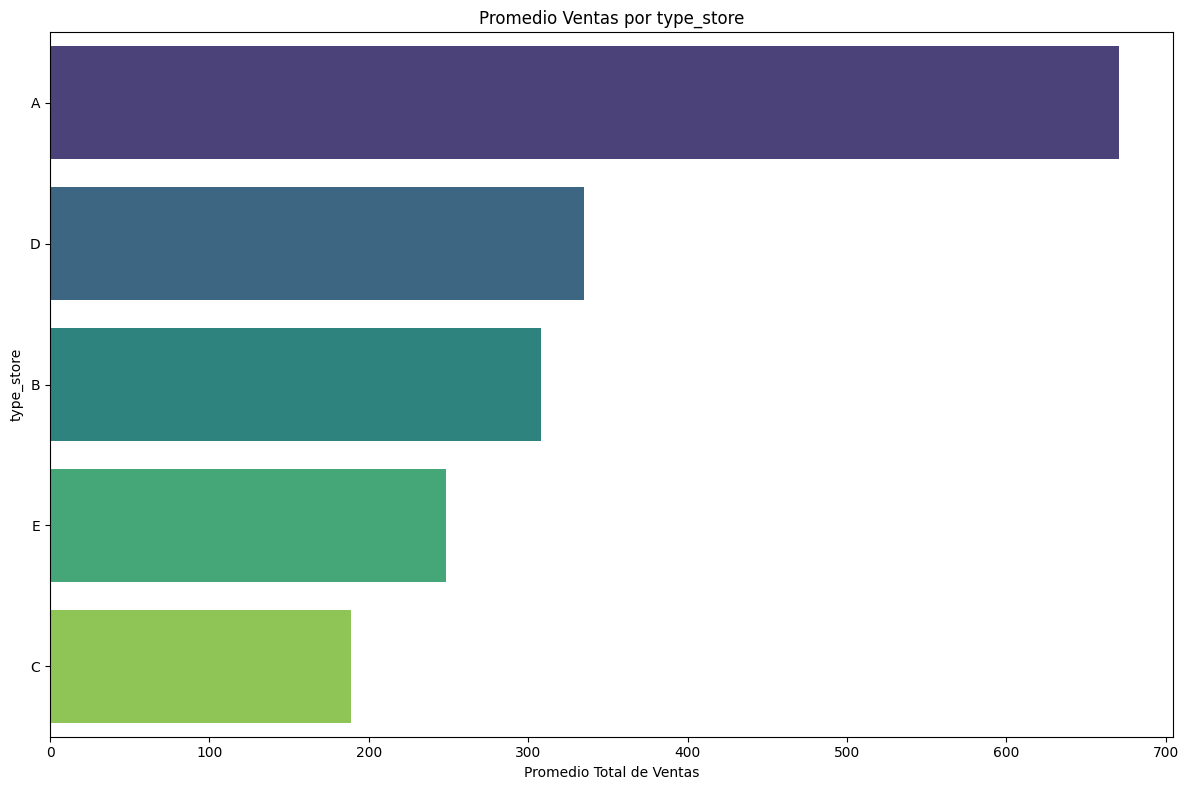

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_22444\43422427.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


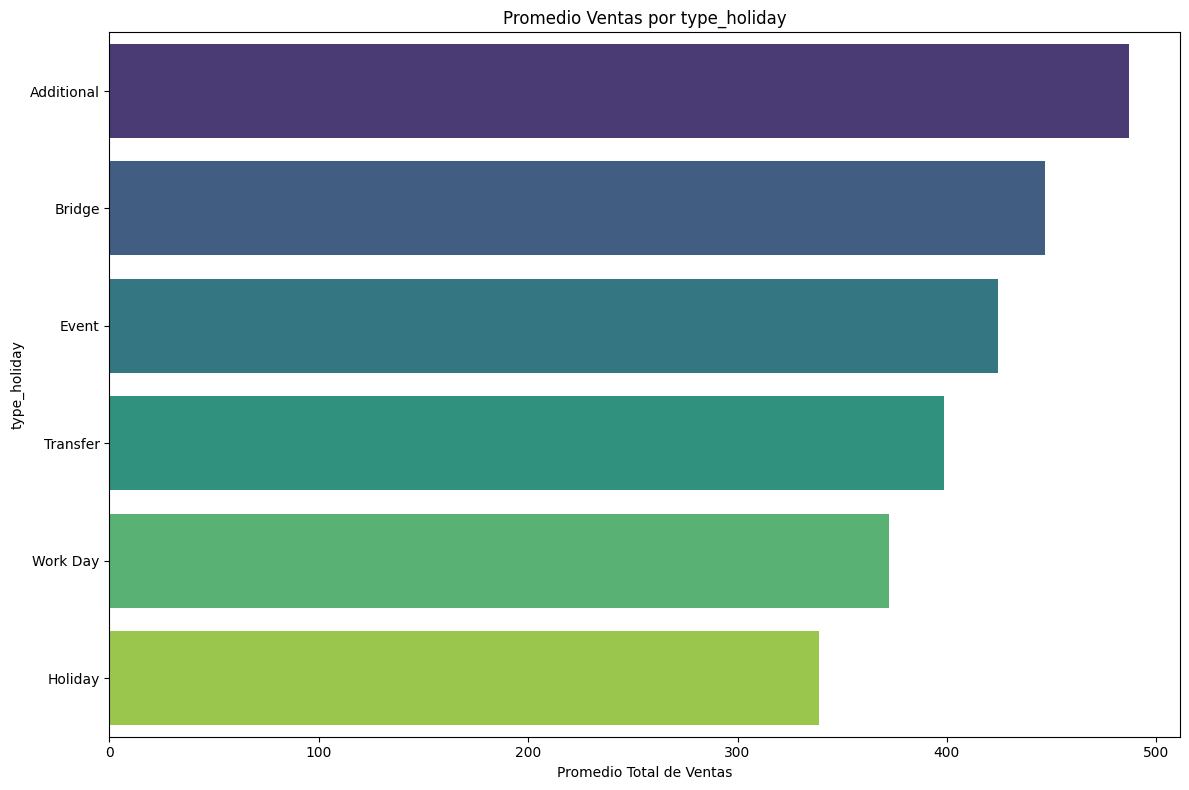

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_22444\43422427.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


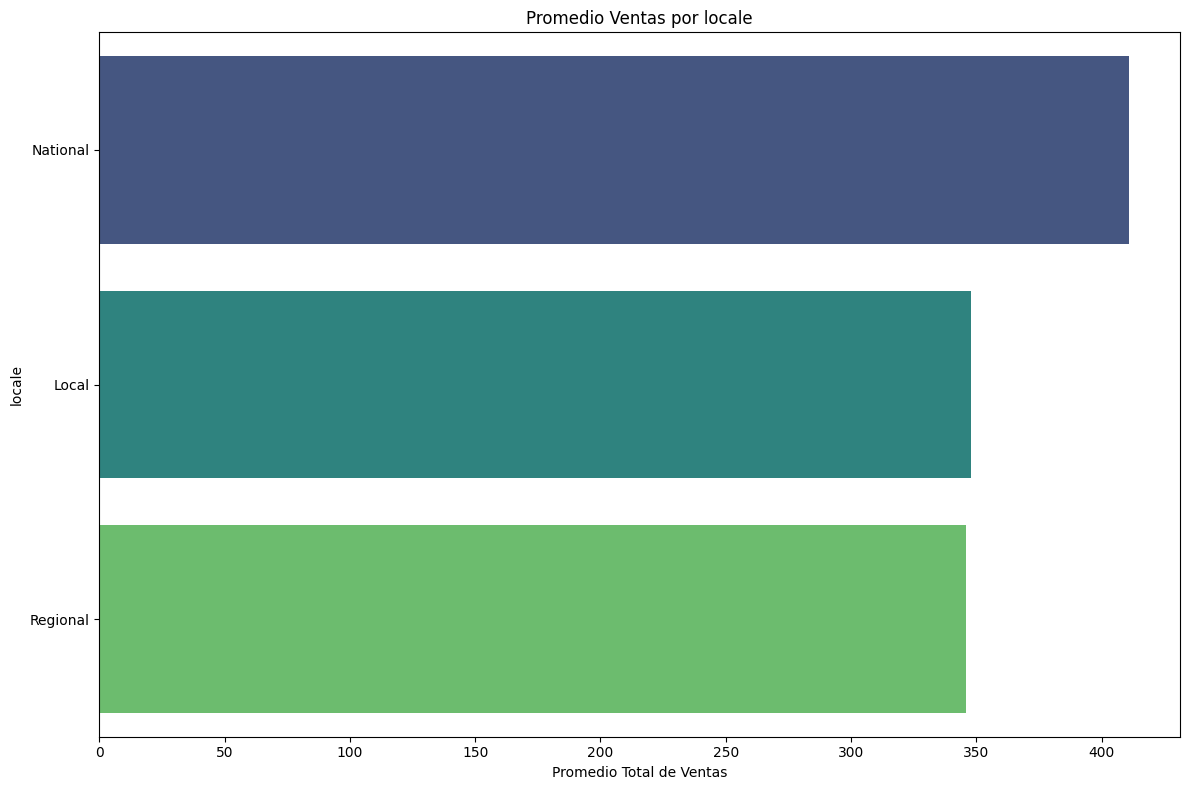

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_22444\43422427.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


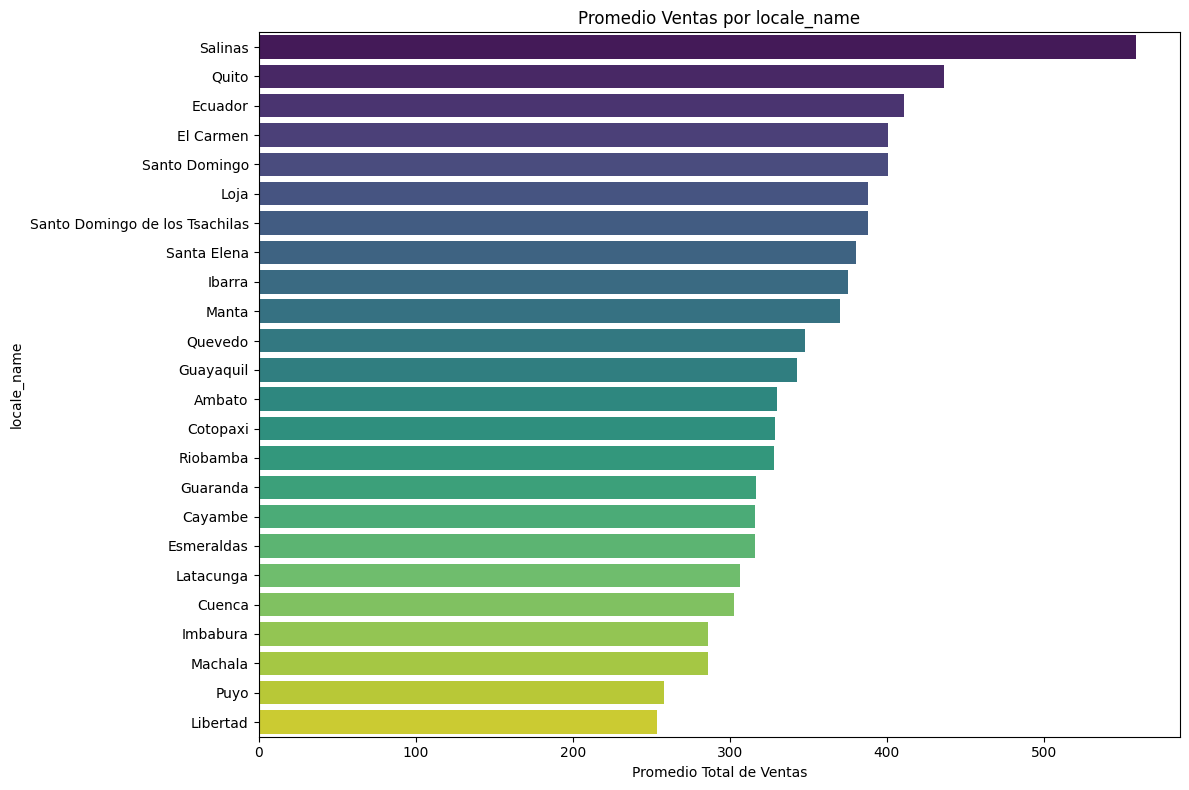

C:\Users\alejandrofan\AppData\Local\Temp\ipykernel_22444\43422427.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')


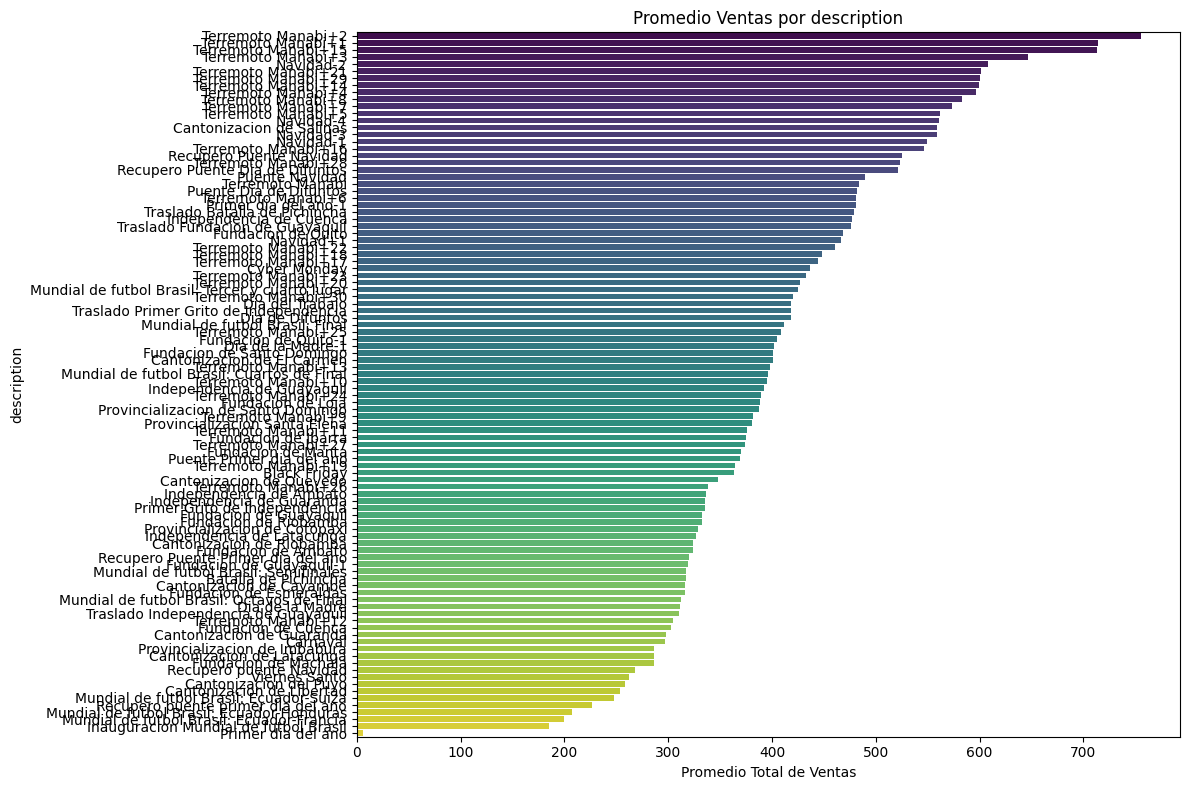

In [35]:
# Iteramos por todas las columnas del dataframe
for column in df_train.columns:
    
    # Comprobamos si la columna es categórica o tipo objeto
    if isinstance(df_train[column].dtype, pd.CategoricalDtype) or df_train[column].dtype == 'object':
        
        plt.figure(figsize=(12, 8))
        
        # 1. Agrupamos y sumamos ventas (esto hace que el gráfico cargue rápido)
        df_grouped = df_train.groupby(column)['sales'].mean().sort_values(ascending=False).reset_index()
        
        # 2. Dibujamos el gráfico de barras
        # Usamos la columna actual en el eje Y y las ventas en el eje X
        sns.barplot(data=df_grouped, x='sales', y=column, palette='viridis')
        
        # 3. Títulos y etiquetas
        plt.title(f'Promedio Ventas por {column}')
        plt.xlabel('Promedio Total de Ventas')
        plt.ylabel(column)
        
        plt.tight_layout()
        plt.show()

El precio de la gasolina influye?

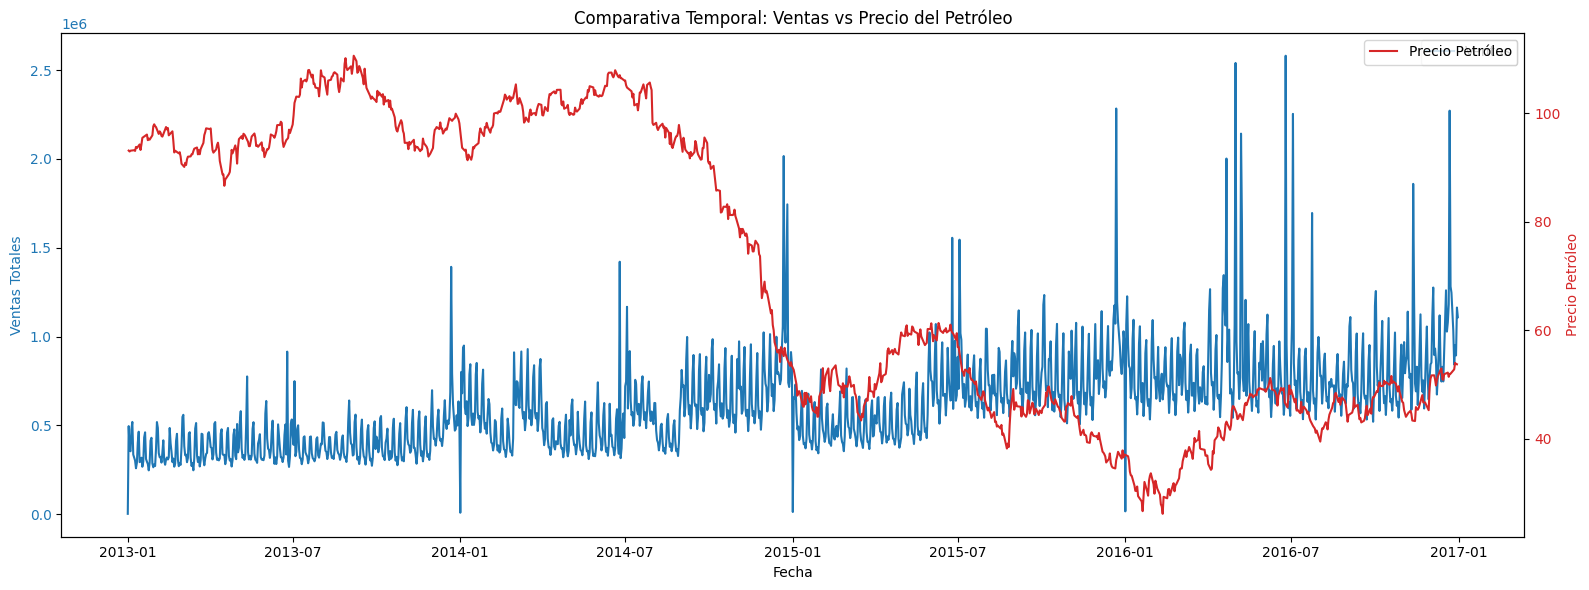

In [36]:
# 1. Agrupamos por fecha para tener una visión clara de la serie temporal
# Asumiendo que tu columna de fecha se llama 'date'
df_temp = df_train.groupby('date').agg({'sales': 'sum', 'oil_price': 'mean'}).reset_index()

fig, ax1 = plt.subplots(figsize=(16, 6))

# --- Primer Eje: Ventas ---
color = 'tab:blue'
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Ventas Totales', color=color)
sns.lineplot(data=df_temp, x='date', y='sales', ax=ax1, color=color, label='Ventas')
ax1.tick_params(axis='y', labelcolor=color)

# --- Segundo Eje: Petróleo ---
ax2 = ax1.twinx() # Crea un segundo eje que comparte el mismo eje X
color = 'tab:red'
ax2.set_ylabel('Precio Petróleo', color=color)
sns.lineplot(data=df_temp, x='date', y='oil_price', ax=ax2, color=color, label='Precio Petróleo')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Comparativa Temporal: Ventas vs Precio del Petróleo')
fig.tight_layout()
plt.show()